In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist


In [ ]:
CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

In [ ]:
# ──────────────────────────────────────────
# 1. LOAD DATA — USE ONLY 100 TRAIN IMAGES
# ──────────────────────────────────────────
(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist.load_data()

X_train = X_train_full[:100]
y_train = y_train_full[:100]
X_test  = X_test_full[:500]    # 500 test images
y_test  = y_test_full[:500]

# Normalize & reshape to (N, 1, 28, 28)
X_train = X_train[:, np.newaxis, :, :] / 255.0
X_test  = X_test[:,  np.newaxis, :, :] / 255.0
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (100, 1, 28, 28) | Test: (500, 1, 28, 28)


In [ ]:
# ──────────────────────────────────────────
# 2. ACTIVATION FUNCTIONS
# ──────────────────────────────────────────
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(probs, labels):
    N = len(labels)
    return -np.log(probs[np.arange(N), labels] + 1e-9).mean()

In [ ]:
# ──────────────────────────────────────────
# 3. CONVOLUTION LAYER (from scratch)
# ──────────────────────────────────────────
def conv2d_forward(X, W, b, stride=1, pad=1):
    N, C_in, H, Wi = X.shape
    C_out, _, kH, kW = W.shape
    X_pad = np.pad(X, ((0,0),(0,0),(pad,pad),(pad,pad)))
    H_out = (H + 2*pad - kH) // stride + 1
    W_out = (Wi + 2*pad - kW) // stride + 1
    out = np.zeros((N, C_out, H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            patch = X_pad[:, :, i*stride:i*stride+kH, j*stride:j*stride+kW]
            out[:, :, i, j] = np.tensordot(patch, W, axes=([1,2,3],[1,2,3])) + b
    return out, X_pad

In [ ]:
def conv2d_backward(dout, X_pad, W, stride=1, pad=1):
    N, C_in, H_pad, W_pad = X_pad.shape
    C_out, _, kH, kW = W.shape
    _, _, H_out, W_out = dout.shape
    dX_pad = np.zeros_like(X_pad)
    dW = np.zeros_like(W)
    db = dout.sum(axis=(0,2,3))
    for i in range(H_out):
        for j in range(W_out):
            patch = X_pad[:, :, i*stride:i*stride+kH, j*stride:j*stride+kW]
            dW += np.tensordot(dout[:, :, i, j], patch, axes=([0],[0])).reshape(dW.shape)
            dX_pad[:, :, i*stride:i*stride+kH, j*stride:j*stride+kW] += \
                np.tensordot(dout[:, :, i, j], W, axes=([1],[0]))
    dX = dX_pad[:, :, pad:-pad, pad:-pad]
    return dX, dW, db


In [ ]:
# ──────────────────────────────────────────
# 4. MAX POOLING (from scratch)
# ──────────────────────────────────────────
def maxpool_forward(X, pool=2, stride=2):
    N, C, H, W = X.shape
    H_out = (H - pool) // stride + 1
    W_out = (W - pool) // stride + 1
    out  = np.zeros((N, C, H_out, W_out))
    mask = np.zeros_like(X)
    for i in range(H_out):
        for j in range(W_out):
            patch = X[:, :, i*stride:i*stride+pool, j*stride:j*stride+pool]
            max_v = patch.max(axis=(2,3), keepdims=True)
            out[:, :, i, j] = max_v[:, :, 0, 0]
            mask[:, :, i*stride:i*stride+pool, j*stride:j*stride+pool] += (patch == max_v)
    return out, mask


In [ ]:
def maxpool_backward(dout, mask, pool=2, stride=2):
    dX = np.zeros_like(mask)
    _, _, H_out, W_out = dout.shape
    for i in range(H_out):
        for j in range(W_out):
            local = mask[:, :, i*stride:i*stride+pool, j*stride:j*stride+pool]
            norm  = local.sum(axis=(2,3), keepdims=True)
            norm[norm == 0] = 1
            dX[:, :, i*stride:i*stride+pool, j*stride:j*stride+pool] += \
                local / norm * dout[:, :, i:i+1, j:j+1]
    return dX

In [ ]:
# ──────────────────────────────────────────
# 5. FULLY CONNECTED LAYER (from scratch)
# ──────────────────────────────────────────
def fc_forward(X, W, b):
    return X @ W + b

def fc_backward(dout, X, W):
    return dout @ W.T, X.T @ dout, dout.sum(axis=0)

In [ ]:
# ──────────────────────────────────────────
# 6. WEIGHT INITIALIZATION
# ──────────────────────────────────────────
np.random.seed(42)

W1 = np.random.randn(8,  1, 3, 3) * np.sqrt(2.0 / (1*3*3))   # Conv1: 8 filters
b1 = np.zeros(8)
W2 = np.random.randn(16, 8, 3, 3) * np.sqrt(2.0 / (8*3*3))   # Conv2: 16 filters
b2 = np.zeros(16)
# 28x28 → pool → 14x14 → pool → 7x7, with 16 channels = 784
W3 = np.random.randn(16*7*7, 64) * np.sqrt(2.0 / (16*7*7))   # FC1
b3 = np.zeros(64)
W4 = np.random.randn(64, 10) * np.sqrt(2.0 / 64)              # FC2
b4 = np.zeros(10)

In [ ]:
# ──────────────────────────────────────────
# 7. FORWARD PASS
# ──────────────────────────────────────────
def forward(X):
    c1, Xp1 = conv2d_forward(X, W1, b1);   a1 = relu(c1)
    p1, m1  = maxpool_forward(a1)

    c2, Xp2 = conv2d_forward(p1, W2, b2);  a2 = relu(c2)
    p2, m2  = maxpool_forward(a2)

    flat = p2.reshape(p2.shape[0], -1)
    f1   = fc_forward(flat, W3, b3);       af1 = relu(f1)
    f2   = fc_forward(af1,  W4, b4)
    probs = softmax(f2)

    return probs, (X, Xp1, c1, a1, p1, m1, Xp2, c2, a2, p2, m2, flat, f1, af1)

In [ ]:

# ──────────────────────────────────────────
# 8. BACKWARD PASS + WEIGHT UPDATE (SGD)
# ──────────────────────────────────────────
def backward(probs, y_batch, cache, lr=0.01):
    global W1, b1, W2, b2, W3, b3, W4, b4
    X, Xp1, c1, a1, p1, m1, Xp2, c2, a2, p2, m2, flat, f1, af1 = cache
    N = len(y_batch)

    # Output gradient
    dscores = probs.copy()
    dscores[np.arange(N), y_batch] -= 1
    dscores /= N

    # FC2 → FC1
    daf1, dW4, db4 = fc_backward(dscores, af1, W4)
    df1 = daf1 * relu_grad(f1)
    dflat, dW3, db3 = fc_backward(df1, flat, W3)

    # Unflatten → Pool2 → Conv2
    dp2 = dflat.reshape(p2.shape)
    da2 = maxpool_backward(dp2, m2)
    dc2 = da2 * relu_grad(c2)
    dp1, dW2, db2_g = conv2d_backward(dc2, Xp2, W2)

    # Pool1 → Conv1
    da1 = maxpool_backward(dp1, m1)
    dc1 = da1 * relu_grad(c1)
    _,   dW1, db1_g = conv2d_backward(dc1, Xp1, W1)

    # SGD update
    W1 -= lr*dW1; b1 -= lr*db1_g
    W2 -= lr*dW2; b2 -= lr*db2_g
    W3 -= lr*dW3; b3 -= lr*db3
    W4 -= lr*dW4; b4 -= lr*db4


In [ ]:
# ──────────────────────────────────────────
# 9. TRAINING LOOP
# ──────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 10
LR         = 0.05

train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    perm = np.random.permutation(len(X_train))
    Xs, ys = X_train[perm], y_train[perm]
    total_loss, correct = 0, 0

    for s in range(0, len(X_train), BATCH_SIZE):
        Xb, yb = Xs[s:s+BATCH_SIZE], ys[s:s+BATCH_SIZE]
        probs, cache = forward(Xb)
        total_loss  += cross_entropy_loss(probs, yb)
        correct     += (probs.argmax(1) == yb).sum()
        backward(probs, yb, cache, lr=LR)

    train_losses.append(total_loss / (len(X_train)//BATCH_SIZE))
    train_accs.append(correct / len(X_train) * 100)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.1f}%")

Epoch  10/50 | Loss: 0.4417 | Train Acc: 83.0%
Epoch  20/50 | Loss: 0.0968 | Train Acc: 97.0%
Epoch  30/50 | Loss: 0.0259 | Train Acc: 100.0%
Epoch  40/50 | Loss: 0.0110 | Train Acc: 100.0%
Epoch  50/50 | Loss: 0.0062 | Train Acc: 100.0%


In [ ]:
# ──────────────────────────────────────────
# 10. TEST EVALUATION
# ──────────────────────────────────────────
test_probs, _ = forward(X_test)
test_preds    = test_probs.argmax(axis=1)
test_acc      = (test_preds == y_test).mean() * 100
print(f"\nTest Accuracy: {test_acc:.1f}%")


Test Accuracy: 71.0%


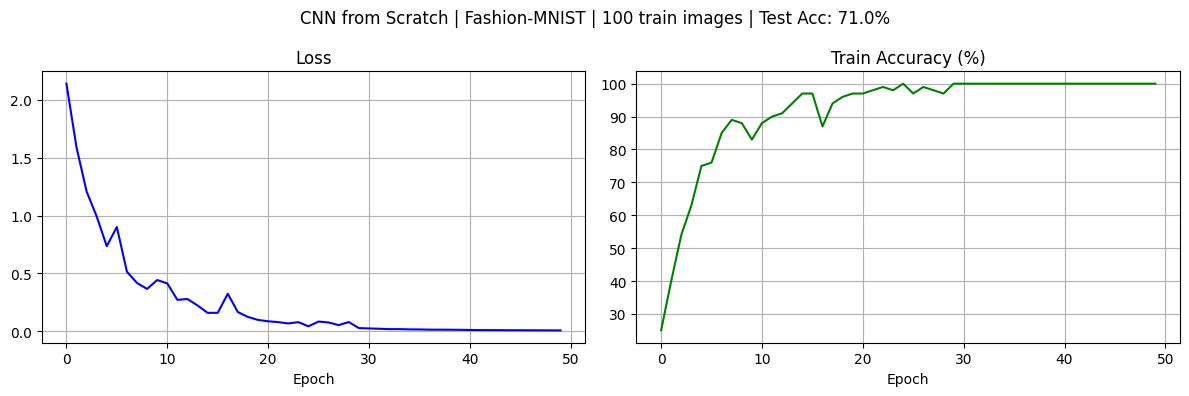

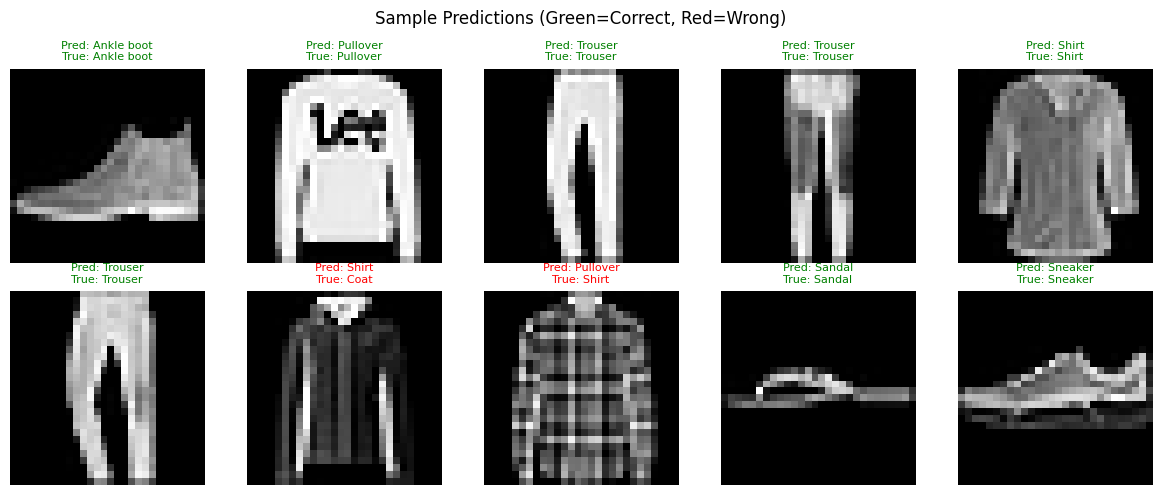

In [ ]:
# ──────────────────────────────────────────
# 11. PLOTS
# ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, 'b-'); axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(train_accs,   'g-'); axes[1].set_title('Train Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].grid(True)
plt.suptitle(f'CNN from Scratch | Fashion-MNIST | 100 train images | Test Acc: {test_acc:.1f}%')
plt.tight_layout(); plt.show()

# Show sample predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i, 0], cmap='gray')
    pred = CLASS_NAMES[test_preds[i]]
    true = CLASS_NAMES[y_test[i]]
    ax.set_title(f"Pred: {pred}\nTrue: {true}",
                 color='green' if pred==true else 'red', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout(); plt.show()